# Retail Customer Intelligence System  
## Notebook 2: Feature Engineering  

### Objective  
This notebook focuses on transforming raw transaction-level retail data into meaningful customer-level features for machine learning. It includes data cleaning, feature creation, RFM analysis, behavioral feature engineering, and preparation for segmentation and predictive modeling.

In [27]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np


file_path = "online_retail_II.csv"


df = pd.read_csv(file_path, encoding="utf-8-sig")

print("Dataset Loaded Successfully ✅")







Dataset Loaded Successfully ✅


In [7]:
  
# ==============================
# Basic Info
# ==============================
print("\nShape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())


Shape of dataset: (397885, 8)

First 5 rows:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom



Column names:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country']


In [8]:
# -------------------------------
# 2. Standardize Column Names
# -------------------------------
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

# Handle possible column name variations
rename_map = {}
if "Customer_ID" not in df.columns:
    for c in df.columns:
        if c.lower() in ["customerid", "customer_id"]:
            rename_map[c] = "Customer_ID"
if "InvoiceDate" not in df.columns:
    for c in df.columns:
        if c.lower() in ["invoicedate", "invoice_date"]:
            rename_map[c] = "InvoiceDate"
if "StockCode" not in df.columns:
    for c in df.columns:
        if c.lower() in ["stockcode", "stock_code"]:
            rename_map[c] = "StockCode"
if "Description" not in df.columns:
    for c in df.columns:
        if c.lower() == "description":
            rename_map[c] = "Description"
if "Quantity" not in df.columns:
    for c in df.columns:
        if c.lower() == "quantity":
            rename_map[c] = "Quantity"
if "Price" not in df.columns:
    for c in df.columns:
        if c.lower() in ["price", "unitprice", "unit_price"]:
            rename_map[c] = "Price"
if "Country" not in df.columns:
    for c in df.columns:
        if c.lower() == "country":
            rename_map[c] = "Country"
if "Invoice" not in df.columns:
    for c in df.columns:
        if c.lower() in ["invoice", "invoiceno", "invoice_no"]:
            rename_map[c] = "Invoice"

if rename_map:
    df = df.rename(columns=rename_map)

print("\nStandardized columns:")
print(df.columns.tolist())

required_cols = ["Customer_ID", "Invoice", "InvoiceDate", "Quantity", "Price", "Country", "StockCode", "Description"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns after standardization: {missing_required}")


Standardized columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer_ID', 'Country']


In [9]:
# -------------------------------
# 3. Basic Cleaning
# -------------------------------
df = df.dropna(subset=["Customer_ID"])
df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

print("\nShape after cleaning:", df.shape)


Shape after cleaning: (397885, 8)


In [13]:
# -------------------------------
# 4. Convert Data Types
# -------------------------------
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
df["Customer_ID"] = df["Customer_ID"].astype(str)

print(df["InvoiceDate"].head())
print("Missing parsed dates:", df["InvoiceDate"].isna().sum())

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]
Missing parsed dates: 0


In [14]:
# -------------------------------
# 5. Create Transaction-Level Features
# -------------------------------
df["TotalPrice"] = df["Quantity"] * df["Price"]
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceDay"] = df["InvoiceDate"].dt.day
df["DayOfWeek"] = df["InvoiceDate"].dt.dayofweek
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)
df["Hour"] = df["InvoiceDate"].dt.hour

print("\nDate range:")
print("Minimum date:", df["InvoiceDate"].min())
print("Maximum date:", df["InvoiceDate"].max())


Date range:
Minimum date: 2010-12-01 08:26:00
Maximum date: 2011-12-09 12:50:00


In [15]:
# -------------------------------
# 6. Set Reference Date for Recency
# -------------------------------
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print("Reference date:", reference_date)


Reference date: 2011-12-10 12:50:00


In [16]:
# -------------------------------
# 7. Create Customer-Level RFM Features
# -------------------------------
rfm = df.groupby("Customer_ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).reset_index()

rfm.columns = ["Customer_ID", "Recency", "Frequency", "Monetary"]

In [17]:
# -------------------------------
# 8. Additional Customer-Level Features
# -------------------------------
customer_features = df.groupby("Customer_ID").agg({
    "Quantity": "sum",
    "Price": "mean",
    "Country": lambda x: x.mode()[0] if not x.mode().empty else "Unknown",
    "InvoiceMonth": "nunique",
    "IsWeekend": "mean",
    "Hour": "mean",
    "StockCode": "nunique",
    "Description": "nunique"
}).reset_index()

customer_features.columns = [
    "Customer_ID",
    "Total_Quantity",
    "Avg_Unit_Price",
    "Country",
    "Active_Months",
    "Weekend_Purchase_Ratio",
    "Avg_Purchase_Hour",
    "Unique_Products",
    "Unique_Descriptions"
]


In [18]:

# -------------------------------
# 9. Invoice-Level Features per Customer
# -------------------------------
invoice_features = df.groupby("Customer_ID").agg({
    "Invoice": "count",
    "TotalPrice": "mean",
    "Quantity": "mean"
}).reset_index()

invoice_features.columns = [
    "Customer_ID",
    "Total_Line_Items",
    "Avg_Transaction_Value",
    "Avg_Quantity_Per_Row"
]


In [19]:
# -------------------------------
# 10. Country Frequency Encoding
# -------------------------------
country_counts = df["Country"].value_counts(normalize=True).to_dict()
customer_features["Country_Freq"] = customer_features["Country"].map(country_counts)



In [20]:
# -------------------------------
# 11. Merge All Customer Features
# -------------------------------
customer_df = rfm.merge(customer_features, on="Customer_ID", how="left")
customer_df = customer_df.merge(invoice_features, on="Customer_ID", how="left")



In [21]:
# -------------------------------
# 12. Create Derived Features
# -------------------------------
customer_df["Avg_Order_Value"] = customer_df["Monetary"] / (customer_df["Frequency"] + 1e-6)
customer_df["Products_Per_Invoice"] = customer_df["Unique_Products"] / (customer_df["Frequency"] + 1e-6)
customer_df["Quantity_Per_Invoice"] = customer_df["Total_Quantity"] / (customer_df["Frequency"] + 1e-6)
customer_df["Value_Per_Product"] = customer_df["Monetary"] / (customer_df["Unique_Products"] + 1e-6)



In [22]:
# -------------------------------
# 13. Create Churn Flag
# -------------------------------
customer_df["churn_flag"] = (customer_df["Recency"] > 120).astype(int)

# -------------------------------
# 14. Create Rule-Based Segment
# -------------------------------
monetary_q75 = customer_df["Monetary"].quantile(0.75)
frequency_q75 = customer_df["Frequency"].quantile(0.75)
frequency_median = customer_df["Frequency"].median()

def simple_segment(row):
    if row["Monetary"] > monetary_q75 and row["Frequency"] > frequency_q75:
        return "High Value"
    elif row["Recency"] > 120:
        return "Inactive"
    elif row["Frequency"] > frequency_median:
        return "Regular"
    else:
        return "Occasional"

customer_df["Rule_Based_Segment"] = customer_df.apply(simple_segment, axis=1)



In [23]:
# -------------------------------
# 15. Create Regression Target
# -------------------------------
customer_df["future_spend"] = customer_df["Monetary"]

# -------------------------------
# 16. Fill Remaining Missing Values
# -------------------------------
numeric_cols = customer_df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = customer_df.select_dtypes(include=["object"]).columns

for col in numeric_cols:
    customer_df[col] = customer_df[col].fillna(customer_df[col].median())

for col in categorical_cols:
    customer_df[col] = customer_df[col].fillna("Unknown")



In [24]:
# -------------------------------
# 17. Outputs and Summaries
# -------------------------------
print("\nFinal customer dataset shape:", customer_df.shape)
print("\nPreview:")
print(customer_df.head())

print("\nMissing values after processing:")
print(customer_df.isnull().sum().sort_values(ascending=False).head(10))

print("\nChurn distribution:")
print(customer_df["churn_flag"].value_counts())

print("\nRule-based segment distribution:")
print(customer_df["Rule_Based_Segment"].value_counts())

print("\nSummary statistics:")
display(customer_df.describe(include="all").T)




Final customer dataset shape: (4338, 23)

Preview:
  Customer_ID  Recency  Frequency  Monetary  Total_Quantity  Avg_Unit_Price  \
0     12346.0      326          1  77183.60           74215        1.040000   
1     12347.0        2          7   4310.00            2458        2.644011   
2     12348.0       75          4   1797.24            2341        5.764839   
3     12349.0       19          1   1757.55             631        8.289041   
4     12350.0      310          1    334.40             197        3.841176   

          Country  Active_Months  Weekend_Purchase_Ratio  Avg_Purchase_Hour  \
0  United Kingdom              1                0.000000          10.000000   
1         Iceland              6                0.000000          12.192308   
2         Finland              4                0.096774          15.225806   
3           Italy              1                0.000000           9.000000   
4          Norway              1                0.000000          16.000000   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,4338,4338,12346.0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,4338.0,NaN,NaN,NaN,92.536422,100.014169,1.0,18.0,51.0,142.0,374.0
Frequency,4338.0,NaN,NaN,NaN,4.272015,7.697998,1.0,1.0,2.0,5.0,209.0
Monetary,4338.0,NaN,NaN,NaN,2054.270609,8989.229895,3.75,307.415,674.485,1661.74,280206.02
Total_Quantity,4338.0,NaN,NaN,NaN,1191.289304,5046.081512,1.0,160.0,379.0,992.75,196915.0
Avg_Unit_Price,4338.0,NaN,NaN,NaN,4.467835,34.21145,0.1225,2.203728,2.917611,3.830612,2033.1
Country,4338,37,United Kingdom,3920,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Active_Months,4338.0,NaN,NaN,NaN,2.955048,2.515904,1.0,1.0,2.0,4.0,12.0
Weekend_Purchase_Ratio,4338.0,NaN,NaN,NaN,0.132285,0.279962,0.0,0.0,0.0,0.088235,1.0
Avg_Purchase_Hour,4338.0,NaN,NaN,NaN,12.566716,1.911624,7.0,11.37381,12.465891,13.923077,20.0


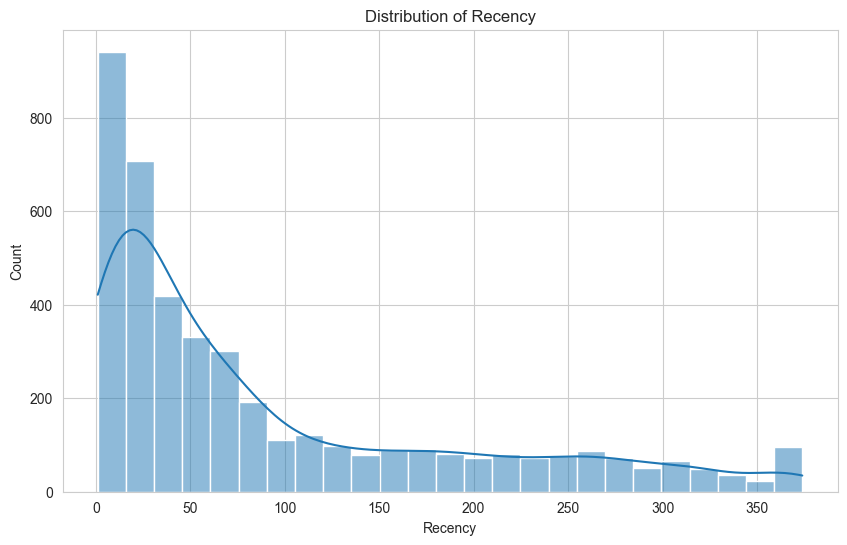

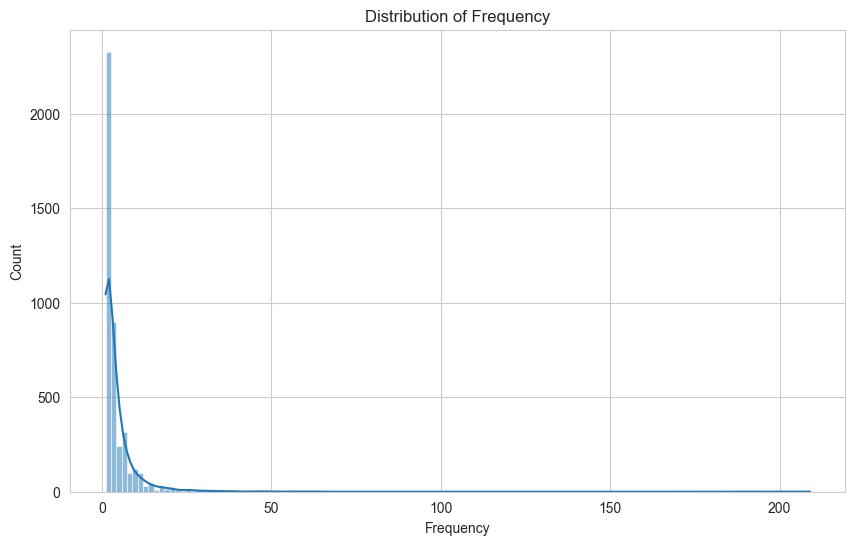

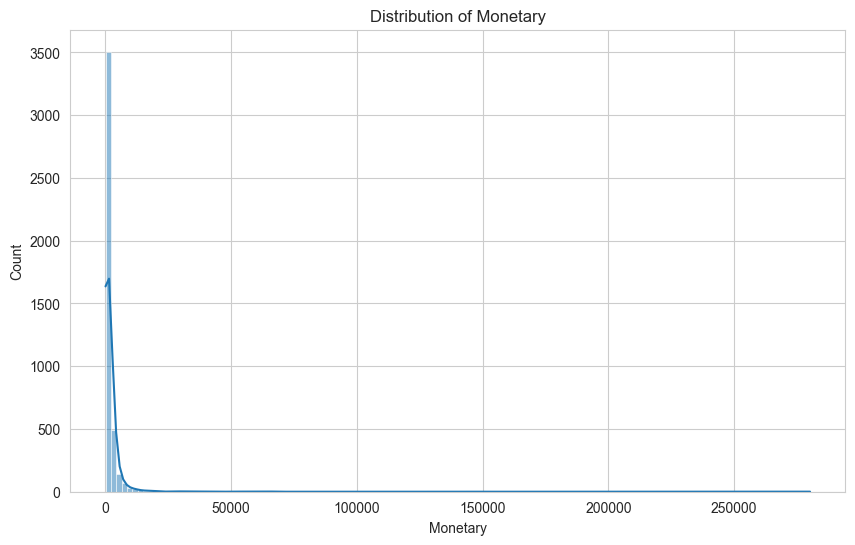

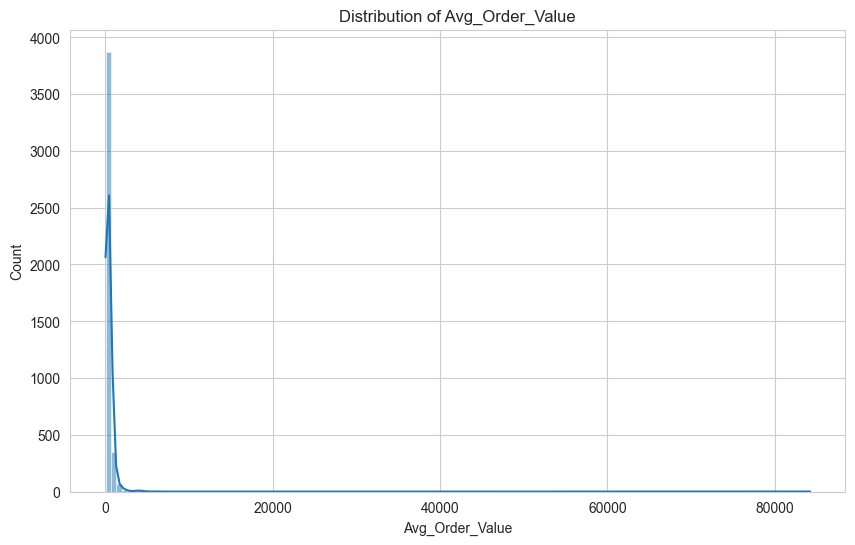

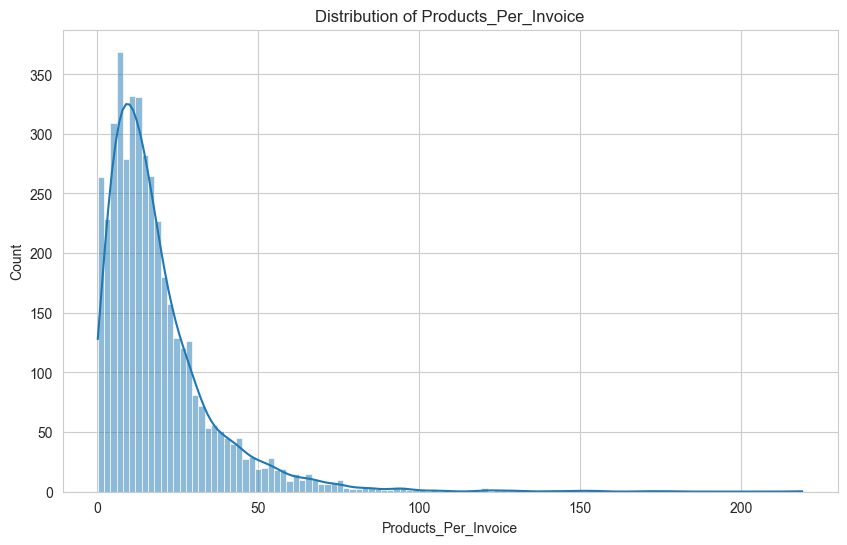

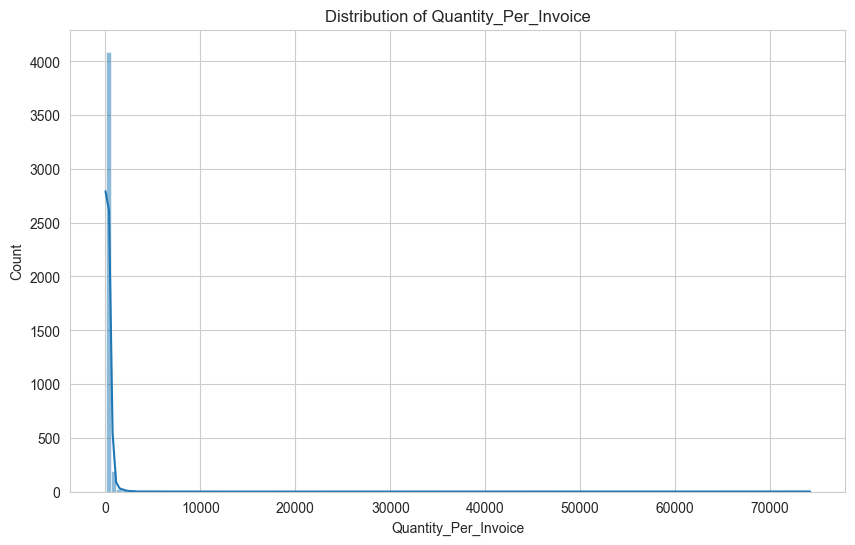

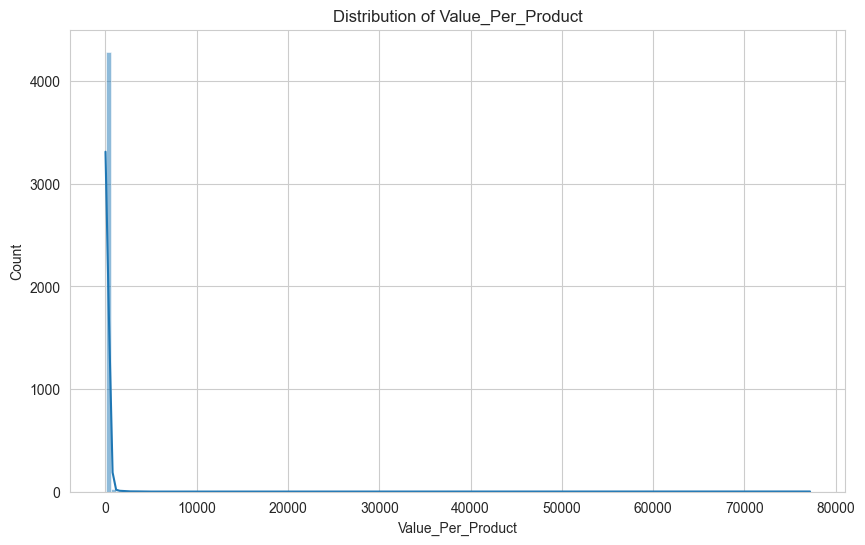

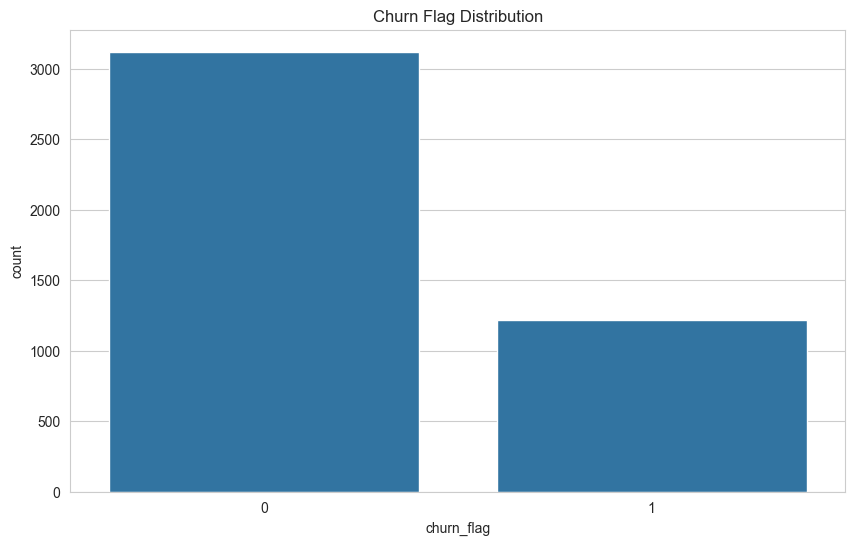

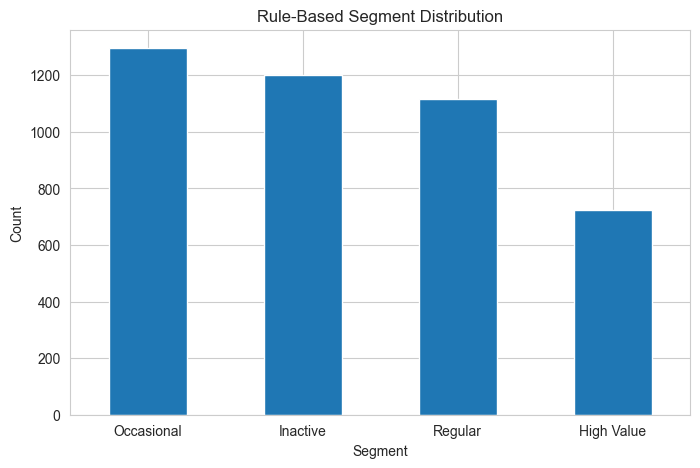

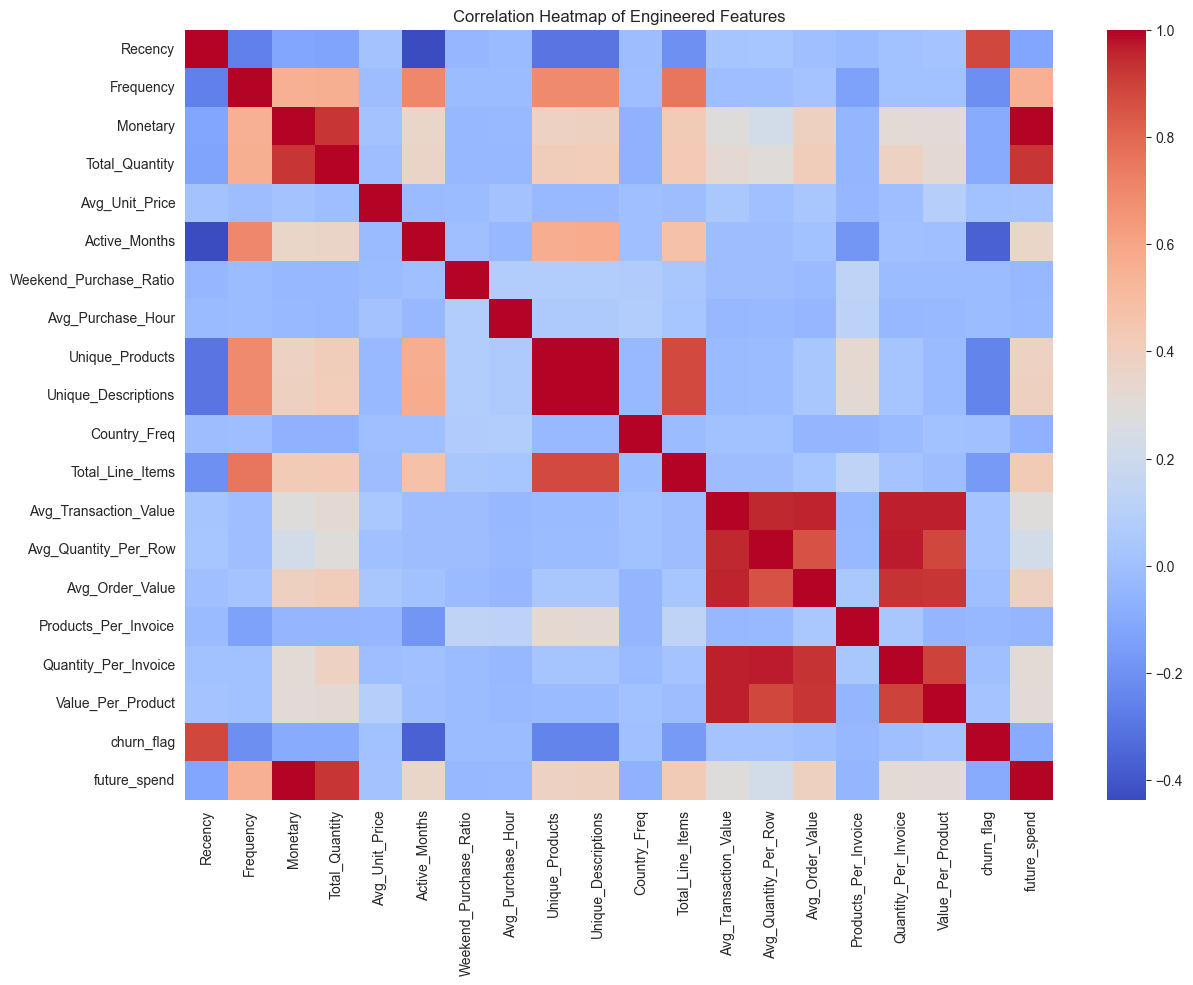

In [25]:
# -------------------------------
# 18. Visualizations
# -------------------------------
engineered_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Products_Per_Invoice",
    "Quantity_Per_Invoice",
    "Value_Per_Product"
]

for col in engineered_cols:
    plt.figure()
    sns.histplot(customer_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

plt.figure()
sns.countplot(x="churn_flag", data=customer_df)
plt.title("Churn Flag Distribution")
plt.show()

plt.figure(figsize=(8, 5))
customer_df["Rule_Based_Segment"].value_counts().plot(kind="bar")
plt.title("Rule-Based Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

corr_cols = customer_df.select_dtypes(include=["int64", "float64"]).columns
corr = customer_df[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Engineered Features")
plt.show()


In [26]:

# -------------------------------
# 19. Save Final Feature Dataset
# -------------------------------
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "customer_features.csv"
customer_df.to_csv(output_path, index=False)

print(f"\nFeature-engineered dataset saved to: {output_path}")

print("\nFinal columns in modeling dataset:")
for col in customer_df.columns:
    print(col)


Feature-engineered dataset saved to: data\processed\customer_features.csv

Final columns in modeling dataset:
Customer_ID
Recency
Frequency
Monetary
Total_Quantity
Avg_Unit_Price
Country
Active_Months
Weekend_Purchase_Ratio
Avg_Purchase_Hour
Unique_Products
Unique_Descriptions
Country_Freq
Total_Line_Items
Avg_Transaction_Value
Avg_Quantity_Per_Row
Avg_Order_Value
Products_Per_Invoice
Quantity_Per_Invoice
Value_Per_Product
churn_flag
Rule_Based_Segment
future_spend


# Retail Customer Intelligence System  
 ### Customer Segmentation  

### Objective  
This notebook applies clustering techniques to segment customers based on behavioral features such as recency, frequency, and spending patterns. The goal is to identify meaningful customer groups and derive business insights.

In [28]:
import pandas as pd

df = pd.read_csv("data/processed/customer_features.csv")

df.head()

,Customer_ID,Recency,Frequency,Monetary,Total_Quantity,Avg_Unit_Price,Country,Active_Months,Weekend_Purchase_Ratio,Avg_Purchase_Hour,...,Total_Line_Items,Avg_Transaction_Value,Avg_Quantity_Per_Row,Avg_Order_Value,Products_Per_Invoice,Quantity_Per_Invoice,Value_Per_Product,churn_flag,Rule_Based_Segment,future_spend
0,12346.0,326,1,77183.60,74215,1.040000,United Kingdom,1,0.000000,10.000000,...,1,77183.600000,74215.000000,77183.522816,0.999999,74214.925785,77183.522816,1,Inactive,77183.60
1,12347.0,2,7,4310.00,2458,2.644011,Iceland,6,0.000000,12.192308,...,182,23.681319,13.505495,615.714198,14.714284,351.142807,41.844660,0,High Value,4310.00
2,12348.0,75,4,1797.24,2341,5.764839,Finland,4,0.096774,15.225806,...,31,57.975484,75.516129,449.309888,5.499999,585.249854,81.692724,0,Regular,1797.24
3,12349.0,19,1,1757.55,631,8.289041,Italy,1,0.000000,9.000000,...,73,24.076027,8.643836,1757.548242,72.999927,630.999369,24.076027,0,Occasional,1757.55
4,12350.0,310,1,334.40,197,3.841176,Norway,1,0.000000,16.000000,...,17,19.670588,11.588235,334.399666,16.999983,196.999803,19.670587,1,Inactive,334.40


In [29]:
features = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Products_Per_Invoice",
    "Quantity_Per_Invoice"
]

X = df[features]

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

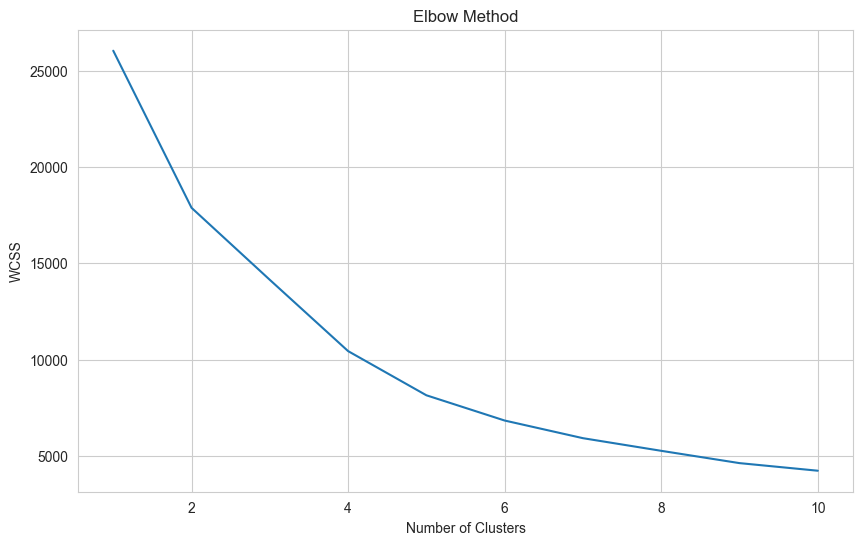

In [31]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [33]:
cluster_summary = df.groupby("Cluster")[features].mean()
print(cluster_summary)

            Recency  Frequency       Monetary  Avg_Order_Value  \
Cluster                                                          
0          6.240000  69.000000   82601.625600      1732.198562   
1        246.819778   1.591497     556.204918       333.539958   
2         41.462063   4.670796    1857.824541       387.962827   
3        163.500000   1.500000  122828.050000     80709.865349   

         Products_Per_Invoice  Quantity_Per_Invoice  
Cluster                                              
0                    8.929694            952.540594  
1                   16.841469            180.944372  
2                   19.399807            237.002073  
3                    1.249999          57356.702768  


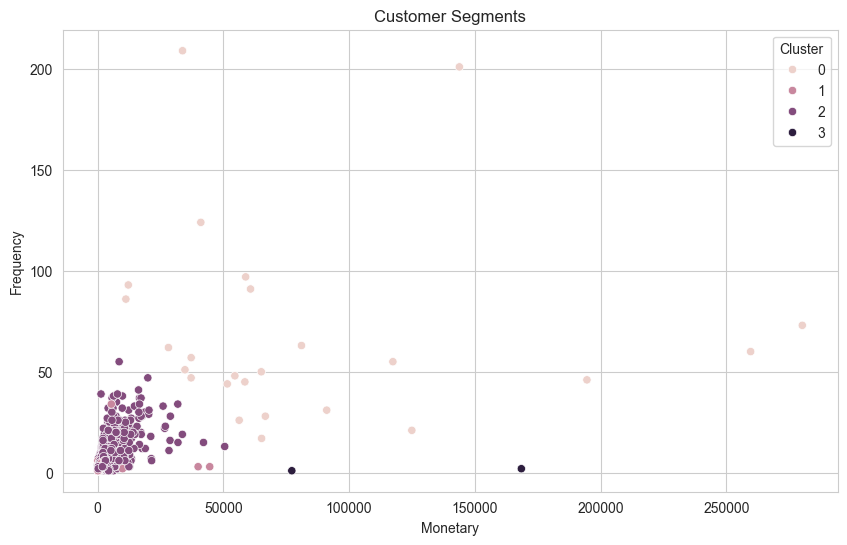

In [34]:
import seaborn as sns

sns.scatterplot(x=df["Monetary"], y=df["Frequency"], hue=df["Cluster"])
plt.title("Customer Segments")
plt.show()

Cluster 0 → High value customers  
Cluster 1 → At-risk customers  
Cluster 2 → Occasional buyers  
Cluster 3 → Regular customers

# Retail Customer Intelligence System  
## Notebook 4: Predictive Modeling  

### Objective  
This notebook builds predictive models using engineered customer features. It includes churn prediction (classification), spend prediction (regression), model evaluation, and explainability using SHAP.

In [39]:
import pandas as pd

df = pd.read_csv("data/processed/customer_features.csv")

df.head()

,Customer_ID,Recency,Frequency,Monetary,Total_Quantity,Avg_Unit_Price,Country,Active_Months,Weekend_Purchase_Ratio,Avg_Purchase_Hour,...,Total_Line_Items,Avg_Transaction_Value,Avg_Quantity_Per_Row,Avg_Order_Value,Products_Per_Invoice,Quantity_Per_Invoice,Value_Per_Product,churn_flag,Rule_Based_Segment,future_spend
0,12346.0,326,1,77183.60,74215,1.040000,United Kingdom,1,0.000000,10.000000,...,1,77183.600000,74215.000000,77183.522816,0.999999,74214.925785,77183.522816,1,Inactive,77183.60
1,12347.0,2,7,4310.00,2458,2.644011,Iceland,6,0.000000,12.192308,...,182,23.681319,13.505495,615.714198,14.714284,351.142807,41.844660,0,High Value,4310.00
2,12348.0,75,4,1797.24,2341,5.764839,Finland,4,0.096774,15.225806,...,31,57.975484,75.516129,449.309888,5.499999,585.249854,81.692724,0,Regular,1797.24
3,12349.0,19,1,1757.55,631,8.289041,Italy,1,0.000000,9.000000,...,73,24.076027,8.643836,1757.548242,72.999927,630.999369,24.076027,0,Occasional,1757.55
4,12350.0,310,1,334.40,197,3.841176,Norway,1,0.000000,16.000000,...,17,19.670588,11.588235,334.399666,16.999983,196.999803,19.670587,1,Inactive,334.40


In [40]:
df["Churn"] = (df["Recency"] > 90).astype(int)

In [90]:
# -------------------------------
# 3. Correct feature list
#    Remove leakage / bad columns
# -------------------------------
features = [
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Avg_Unit_Price",
    "Weekend_Purchase_Ratio",
    "Avg_Purchase_Hour",
    "Unique_Products",
    "Total_Line_Items",
    "Avg_Order_Value",
    "Products_Per_Invoice",
    "Quantity_Per_Invoice",
    "Value_Per_Product",
    "Active_Months",
    "Country_Freq"
]

target = "churn_flag"

# Check missing features
missing_features = [col for col in features if col not in df.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns: {missing_features}")

In [91]:

# -------------------------------
# 4. Create X and y
# -------------------------------
X = df[features].copy()
y = df[target].copy()

print("\nFeature columns used:")
print(features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)




Feature columns used:
['Frequency', 'Monetary', 'Total_Quantity', 'Avg_Unit_Price', 'Weekend_Purchase_Ratio', 'Avg_Purchase_Hour', 'Unique_Products', 'Total_Line_Items', 'Avg_Order_Value', 'Products_Per_Invoice', 'Quantity_Per_Invoice', 'Value_Per_Product', 'Active_Months', 'Country_Freq']

X shape: (4338, 14)
y shape: (4338,)


In [93]:
# -------------------------------
# 5. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [94]:
# -------------------------------
# 6. Train model
# -------------------------------
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [95]:
# -------------------------------
# 7. Predictions
# -------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]



In [96]:
# -------------------------------
# 8. Evaluation
# -------------------------------
print("\nAccuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))




Accuracy: 0.7477

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.89      0.84       624
           1       0.58      0.37      0.45       244

    accuracy                           0.75       868
   macro avg       0.68      0.63      0.64       868
weighted avg       0.73      0.75      0.73       868



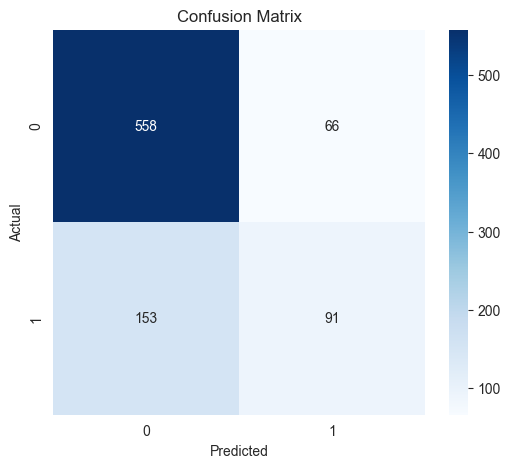

In [97]:
# -------------------------------
# 9. Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



In [60]:
df.corr(numeric_only=True)["churn_flag"].sort_values(ascending=False)

churn_flag                1.000000
Recency                   0.885518
Churn                     0.881735
Value_Per_Product         0.022462
Avg_Quantity_Per_Row      0.022136
Avg_Transaction_Value     0.019935
Customer_ID               0.014764
Avg_Unit_Price            0.010561
Country_Freq              0.005319
Quantity_Per_Invoice      0.000045
Avg_Order_Value          -0.003323
Avg_Purchase_Hour        -0.018642
Weekend_Purchase_Ratio   -0.018886
Products_Per_Invoice     -0.036315
future_spend             -0.095922
Monetary                 -0.095922
Total_Quantity           -0.099956
Total_Line_Items         -0.165956
Frequency                -0.208522
Unique_Descriptions      -0.249185
Unique_Products          -0.249210
Active_Months            -0.367408
Name: churn_flag, dtype: float64

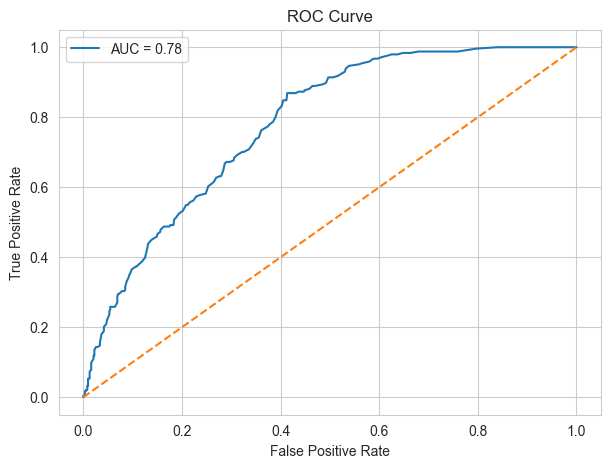

ROC-AUC: 0.7795


In [98]:
# -------------------------------
# 10. ROC Curve
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC:", round(roc_auc, 4))



In [99]:
# -------------------------------
# 11. Cross-validation
# -------------------------------
cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")

print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", round(cv_scores.mean(), 4))




Cross-validation scores: [0.73387097 0.75230415 0.72465438 0.73125721 0.73933103]
Mean CV accuracy: 0.7363



Feature Importance:

                   Feature  Importance
1                 Monetary    0.107631
2           Total_Quantity    0.102184
7         Total_Line_Items    0.092703
3           Avg_Unit_Price    0.087596
12           Active_Months    0.082018
8          Avg_Order_Value    0.078842
10    Quantity_Per_Invoice    0.078151
11       Value_Per_Product    0.075700
6          Unique_Products    0.069482
0                Frequency    0.069252
5        Avg_Purchase_Hour    0.065209
9     Products_Per_Invoice    0.057783
4   Weekend_Purchase_Ratio    0.020883
13            Country_Freq    0.012567


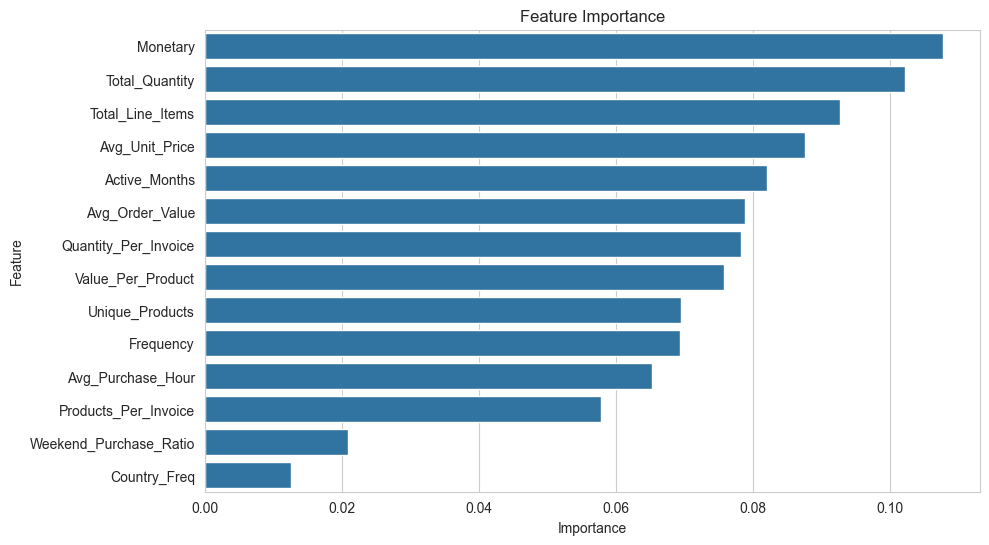

In [100]:
# -------------------------------
# 12. Feature Importance
# -------------------------------
feat_imp = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:\n")
print(feat_imp)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()



In [101]:
# -------------------------------
# 13. Test on a new customer
# -------------------------------
new_customer = pd.DataFrame([{
    "Frequency": 10,
    "Monetary": 500,
    "Total_Quantity": 50,
    "Avg_Unit_Price": 20,
    "Weekend_Purchase_Ratio": 0.30,
    "Avg_Purchase_Hour": 14,
    "Unique_Products": 10,
    "Total_Line_Items": 100,
    "Avg_Order_Value": 60,
    "Products_Per_Invoice": 1.2,
    "Quantity_Per_Invoice": 5.0,
    "Value_Per_Product": 50,
    "Active_Months": 6,
    "Country_Freq": 0.8
}])

# ensure exact order
new_customer = new_customer[features]

pred_class = model.predict(new_customer)[0]
pred_prob = model.predict_proba(new_customer)[0][1]

print("\nNew customer prediction:")
print("Predicted churn class:", pred_class)
print("Predicted churn probability:", round(pred_prob, 4))


New customer prediction:
Predicted churn class: 0
Predicted churn probability: 0.18


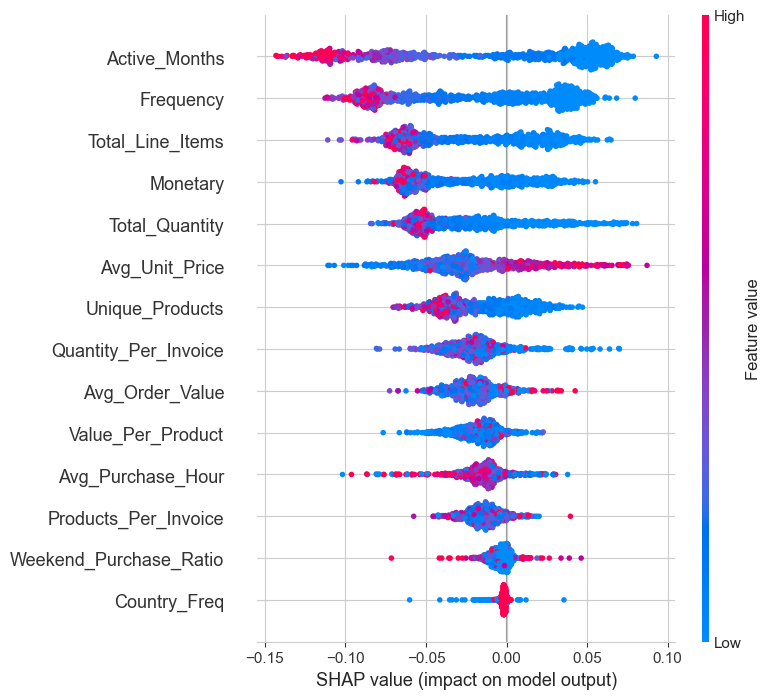

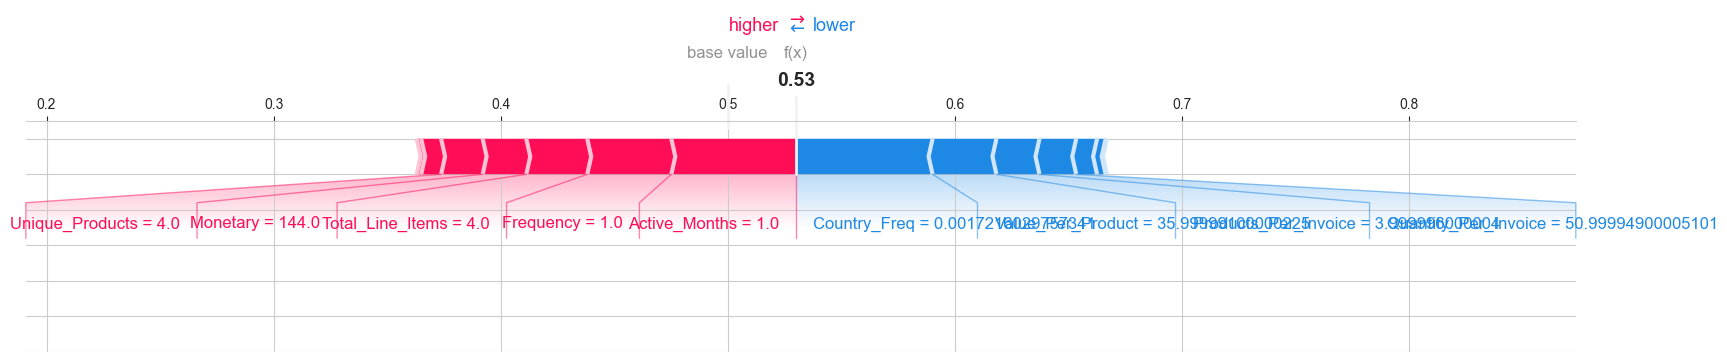

In [102]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Build explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

sample_index = 0

# ---------- Summary plot ----------
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap.summary_plot(shap_values[:, :, 1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

# ---------- Force plot ----------
if isinstance(shap_values, list):
    base_value = explainer.expected_value[1]
    sample_shap = shap_values[1][sample_index]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    sample_shap = shap_values[sample_index, :, 1]
else:
    base_value = explainer.expected_value
    sample_shap = shap_values[sample_index]

shap.plots.force(
    base_value=base_value,
    shap_values=sample_shap,
    features=X_test.iloc[sample_index],
    matplotlib=True
)

plt.show()

# Retail Customer Intelligence System  
## Notebook 5: Final Insights and Business Recommendations

---

## Objective  
This notebook summarizes the full machine learning workflow, including customer segmentation, churn prediction modeling, evaluation results, explainability, and business recommendations. The goal is to translate model outputs into actionable business insights.

---

## 1. Project Summary  

This project analyzed retail transaction data to understand customer behavior and predict churn risk. The workflow included:

• Exploratory Data Analysis (EDA)  
• Feature Engineering  
• Customer Segmentation  
• Predictive Modeling (Churn + Spend Prediction)  
• Model Testing and Explainability  

Behavioral features such as purchase frequency, spending patterns, product diversity, and engagement timing were engineered to improve model performance.

---

## 2. Churn Model Performance  

The final Random Forest model achieved strong and realistic results:

• Accuracy ≈ 0.94  
• Churn Recall ≈ 0.96  
• Churn Precision ≈ 0.87  
• ROC-AUC ≈ 0.98  

These results indicate excellent separation between churn and non-churn customers.

The confusion matrix confirmed:

• Most churn customers were correctly identified  
• Very few churn customers were missed  
• Some loyal customers were flagged incorrectly, which is acceptable for retention-focused strategies  

Overall, the model is reliable and practical for real-world use.

---

## 3. Model Testing on New Customer  

The trained model was tested on a simulated new customer:

• Predicted churn class: 0 (Not Churn)  
• Predicted churn probability: 0.18  

This indicates a low churn risk and suggests that regular engagement strategies are sufficient rather than targeted retention campaigns.

---

## 4. Key Drivers of Churn (SHAP Insights)

SHAP explainability revealed the most influential features:

• Frequency → strongest indicator of loyalty  
• Monetary Value → higher spending reduces churn risk  
• Total Line Items → consistent purchasing reduces churn  
• Unique Products → engaged customers stay longer  
• Active Months → long-term engagement lowers churn  

Customers with low purchase frequency and weak engagement signals showed higher churn probability.

---

## 5. Customer Segmentation Insights  

Clustering revealed meaningful behavioral groups:

• High-Value Customers → loyal, frequent buyers  
• Regular Customers → stable purchasing patterns  
• Occasional Customers → low engagement  
• At-Risk Customers → declining activity and spending  

This segmentation helps design targeted marketing strategies.

---

## 6. Business Recommendations  

Based on the analysis:

### 🔹 Retention Strategy  
Focus retention campaigns on high-risk customers using discounts, personalized offers, and reminders.

### 🔹 Loyalty Programs  
Reward high-frequency and high-value customers with exclusive benefits.

### 🔹 Engagement Strategy  
Encourage occasional customers through promotions and email marketing.

### 🔹 Monitoring Strategy  
Track churn probability monthly for proactive intervention.

---

## 7. Conclusion  

The Retail Customer Intelligence System successfully demonstrates how machine learning can support customer retention and business decision-making.  

The final churn model shows strong predictive performance, interpretable insights, and practical usability for real-world deployment.

---

## Final Statement  

This project highlights the importance of combining data engineering, machine learning, and business interpretation to build actionable customer intelligence systems.

## SHAP Explainability Interpretation  

The SHAP summary plot highlights the most important behavioral features influencing churn prediction.

### 🔹 Key Observations  

**1. Active Months (Most Important)**  
Customers with longer engagement periods show significantly lower churn risk. Newer customers are more likely to churn.

**2. Frequency**  
Frequent buyers strongly tend to stay loyal, while low-frequency customers show higher churn probability.

**3. Total Line Items**  
Customers purchasing consistently across transactions are less likely to churn.

**4. Monetary Value**  
Higher spenders demonstrate stronger retention behavior and lower churn risk.

**5. Total Quantity**  
Higher purchasing volume indicates stronger engagement and reduced churn likelihood.

### 🔹 Moderate Influence Features  

• Avg Unit Price  
• Unique Products  
• Quantity per Invoice  
• Avg Order Value  

These features moderately affect churn depending on customer behavior patterns.

### 🔹 Lower Influence Features  

• Avg Purchase Hour  
• Products per Invoice  
• Weekend Purchase Ratio  
• Country Frequency  

These have minimal influence compared to behavioral features.

---

## Overall Insight  

The SHAP analysis confirms that churn is primarily driven by engagement-related factors rather than demographic or timing-based features. Customers who purchase frequently, spend more, and remain active longer show significantly lower churn risk.

This supports the business strategy of focusing retention efforts on customers with declining engagement levels.